# Job Candidates Final Project

## Objective

A tech company wants to hire new data analysts.  They asked you to create a machine learning model to help them predict whether or not potential job candidates are interested in taking a new job.  The potential candidate pool comes from people  enrolled in a training program. Predicting the interest of potential candidates will help prioritize candidates and reduce time/money spent on recruitment. Your current task is to prepare and optimize the data set that will be used to build the prediction model. At this point, various model will be built and evaluated (logistic regression, decision tree, random forest, etc.)  In order to properly prepare the data set you will need to complete appropriate data preprocessing, EDA, and feature engineering tasks. 

## Data Dictionary

* enrollee_id: Unique ID for the candidate

* city: City code

* city_ development _index: Development index of the city (scaled)

* gender: Gender of the candidate

* relevent_experience: Relevant experience of the candidate in years

* enrolled_university: Type of University course enrolled if any

* education_level: Education level of candidate

* major_discipline: Education major discipline of the candidate

* experience: Candidate total experience in years

* company_size: No of employees in current employer's company

* company_type: Type of current employer

* lastnewjob: Difference in years between previous job and current job

* training_hours: training hours completed

* target: 0 – Not looking for a job change, 1 – Looking for a job change

## Importing the Libraries and Loading Data

In [1]:
import pandas as pd                                     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("job_candidates.csv")

## Data Overview

In [3]:
# Here we will be observing the top 10 rows of the data.

df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


In [4]:
# Here we will be looking at a random sample of the data. 

df.sample(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
3334,19891,city_114,0.926,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,10000+,Pvt Ltd,>4,42,1.0
10125,25829,city_16,0.910,Male,No relevent experience,no_enrollment,Graduate,No Major,9,NaN,NaN,2,56,1.0
3475,733,city_53,0.740,Male,Has relevent experience,Part time course,Graduate,STEM,14,NaN,Pvt Ltd,>4,12,0.0
4223,22562,city_67,0.855,Male,Has relevent experience,no_enrollment,Phd,STEM,>20,<10,Pvt Ltd,>4,92,0.0
2535,1585,city_16,0.910,Male,Has relevent experience,no_enrollment,Masters,STEM,16,1000-4999,Pvt Ltd,2,104,0.0
1373,819,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,3,27,1.0
14492,3721,city_160,0.920,NaN,No relevent experience,no_enrollment,High School,NaN,3,NaN,NaN,NaN,44,0.0
18149,2548,city_104,0.924,Male,Has relevent experience,no_enrollment,Graduate,STEM,10,100-500,Pvt Ltd,1,54,0.0
4281,9721,city_103,0.920,Male,Has relevent experience,no_enrollment,Masters,Arts,>20,1000-4999,NGO,>4,50,1.0
14692,7492,city_16,0.910,Male,Has relevent experience,no_enrollment,Masters,STEM,8,1000-4999,Pvt Ltd,1,56,0.0


Observations: 

I can see that enrollee_id appears to be a bit of a unique identifier which means that it will likely need to be removed later. City will need to be changed in time, city development index looks to already be standardized, there are missing values in gender, education level, major discipline, company size, company type, last new job, and maybe even more. We will be looking further into this later.

In [5]:
# Checking the number of rows and values in the dataframe

df.shape

(19158, 14)

In [6]:
# Here we are checking the data types and information of all the columns.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [7]:
# Here we are checking for duplicate values. This will likely be little to 0 because there is a seemingly unique identifier. Because of this we will check this value again later.

df.duplicated().sum()

np.int64(0)

In [8]:
# Here we are checking for any null values.

df.isna().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [9]:
# Here we are looking at the statistical information for the columns.

df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [10]:
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   22
company_size                  8
company_type                  6
last_new_job                  6
training_hours              241
target                        2
dtype: int64

### Observations

Through this dataframe we have seen that there are a lot of null values and a lot of unique values in sections such as enrollee_id, city, city_development_index, and training_hours. Through our datapreprocessing and feature engineerinng we will fix this and get the dataframe ready for model building.

## Data Preprocessing

### Inconsistent Data

In [11]:
# Checking each value count for inconsistent data.

for item in df:
    print(df[item].value_counts())
    print("---------------------------------")

enrollee_id
8949     1
10660    1
30726    1
18507    1
31273    1
        ..
11547    1
32067    1
14356    1
18051    1
23834    1
Name: count, Length: 19158, dtype: int64
---------------------------------
city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
            ... 
city_129       3
city_111       3
city_121       3
city_140       1
city_171       1
Name: count, Length: 123, dtype: int64
---------------------------------
city_development_index
0.920    5200
0.624    2702
0.910    1533
0.926    1336
0.698     683
         ... 
0.649       4
0.807       4
0.781       3
0.625       3
0.664       1
Name: count, Length: 93, dtype: int64
---------------------------------
gender
Male      13221
Female     1238
Other       191
Name: count, dtype: int64
---------------------------------
relevent_experience
Has relevent experience    13792
No relevent experience      5366
Name: count, dtype: int64
---------------------------------
enrolled_universi

Everything here looks good enough so far. There are no misspellings that I can see and the numeric fields are seen as objects for the moment because many contain fields such as <1 or >4. These will be addressed later.

### Null Values

In [12]:
# Here I am checking what sections have null values so we can see what needs to be addressed.

df.isna().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

#### Multiple Missing Values

In [13]:
# Here we are going to use python to try to find columns with more than 3 missing fields, those fields will then be removed

# Find rows with more than 3 missing values
rows_multiple_missing = df[df.isna().sum(axis=1) > 3]
print(rows_multiple_missing)

# Show columns that are missing in those rows
print(rows_multiple_missing.loc[:, rows_multiple_missing.isna().any()])

# Identify problem columns
problem_columns = rows_multiple_missing.columns[rows_multiple_missing.isna().any()]
print(problem_columns)

# Count how many rows have >3 missing values
print((df.isna().sum(axis=1) > 3).sum())

# Inspect dataset sorted by missing values
print(df.assign(missing_count=df.isna().sum(axis=1))
        .sort_values("missing_count", ascending=False))

# Remove rows with more than 3 missing values
df = df[df.isna().sum(axis=1) <= 3]

       enrollee_id      city  city_development_index gender  \
10           29452   city_21                   0.624    NaN   
13            5826   city_21                   0.624   Male   
14            8722   city_21                   0.624    NaN   
25           14505   city_67                   0.855    NaN   
39           24659   city_71                   0.884   Male   
...            ...       ...                     ...    ...   
19115         6953   city_61                   0.913    NaN   
19118        12211  city_126                   0.479    NaN   
19139         5603   city_21                   0.624    NaN   
19140        11398  city_103                   0.920    NaN   
19157        23834   city_67                   0.855    NaN   

           relevent_experience enrolled_university education_level  \
10      No relevent experience    Full time course     High School   
13      No relevent experience                 NaN             NaN   
14      No relevent experience   

In [14]:
# Here I am checking again the number of null values.

df.isna().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    3824
relevent_experience          0
enrolled_university        204
education_level            147
major_discipline          2064
experience                  33
company_size              5095
company_type              5290
last_new_job               228
training_hours               0
target                       0
dtype: int64

We can see that there is a significant number of fields that were removed by dropping these rows with multiple null values. This made it so the categories that have significant missing values are gone. Now we are going to move onto imputing the null values. 

#### Gender

In [15]:
df['gender'].isna().sum()

np.int64(3824)

In [16]:
# This command is to look at the stastics of the data so we can analyze how they may change after the data is imputed. 

df.gender.describe().T

count     14456
unique        3
top        Male
freq      13043
Name: gender, dtype: object

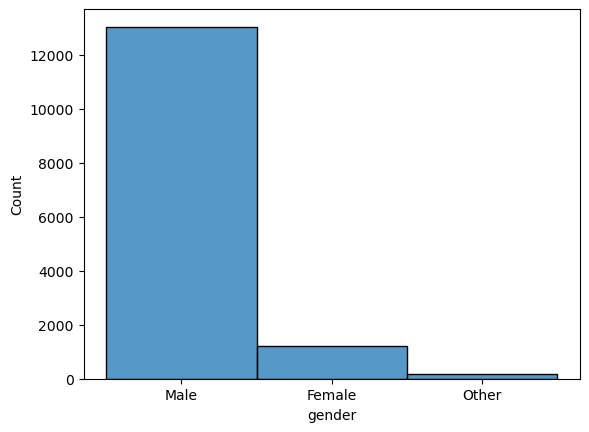

In [17]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['gender']);

Since there is such a large quantity of missing values for gender, I feel that imputing by the mode would not be helpful since it would further oppress the female and other sections. I am going to impute by the columns distribution.

In [18]:
# Get distribution of existing values
probabilities = df['gender'].value_counts(normalize=True)
print(probabilities)

# Fill missing values based on those probabilities
df.loc[df['gender'].isna(), 'gender'] = np.random.choice(
    probabilities.index,
    size=df['gender'].isna().sum(),
    p=probabilities.values)

df['gender'].value_counts(normalize=True)

gender
Male      0.902255
Female    0.085155
Other     0.012590
Name: proportion, dtype: float64


gender
Male      0.903118
Female    0.085284
Other     0.011597
Name: proportion, dtype: float64

In [19]:
# Checking for null values again

df['gender'].isna().sum()

np.int64(0)

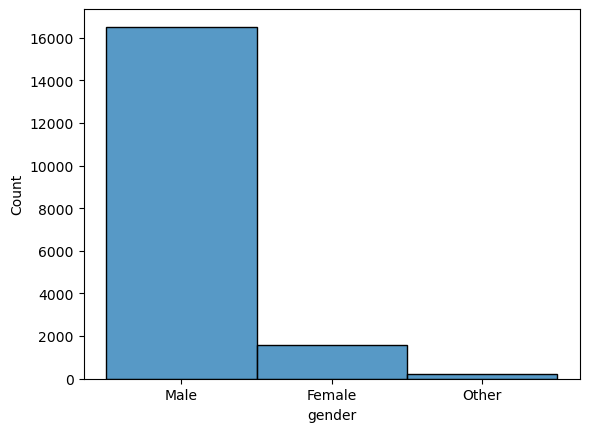

In [20]:
# Making another histogram

sns.histplot(df['gender']);

#### Enrolled University

In [21]:
df['enrolled_university'].isna().sum()

np.int64(204)

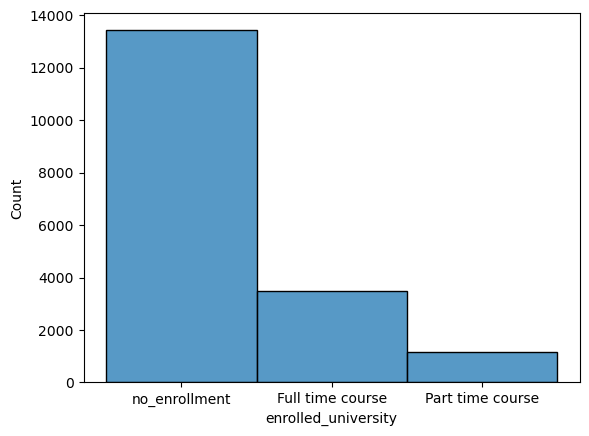

In [22]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['enrolled_university']);

Like gender, I want to impute by the distribution due to the most significant numbers around no_enrollment.

In [23]:
# Get distribution of existing values
probabilities = df['enrolled_university'].value_counts(normalize=True)
print(probabilities)

# Fill missing values based on those probabilities
df.loc[df['enrolled_university'].isna(), 'enrolled_university'] = np.random.choice(
    probabilities.index,
    size=df['enrolled_university'].isna().sum(),
    p=probabilities.values)

df['enrolled_university'].value_counts(normalize=True)

enrolled_university
no_enrollment       0.742421
Full time course    0.193240
Part time course    0.064339
Name: proportion, dtype: float64


enrolled_university
no_enrollment       0.742560
Full time course    0.193435
Part time course    0.064004
Name: proportion, dtype: float64

In [24]:
df['enrolled_university'].isna().sum()

np.int64(0)

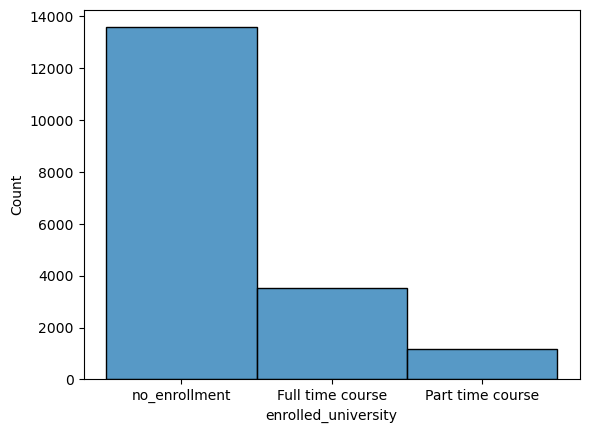

In [25]:
# Creating a second histogram

sns.histplot(df['enrolled_university']);

#### Education Level

In [26]:
df['education_level'].isna().sum()

np.int64(147)

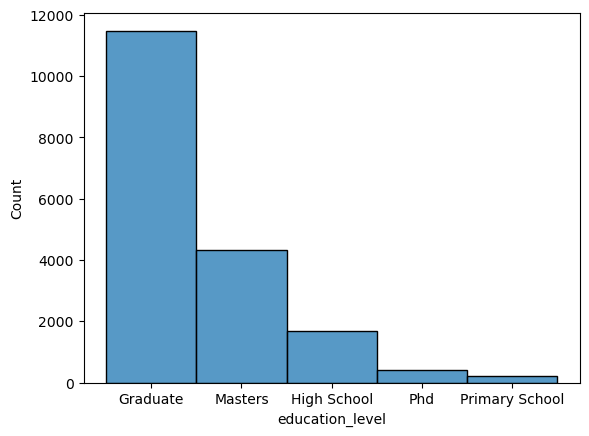

In [27]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['education_level']);

Once again, I am going to impute this categorical information by the statistics.

In [28]:
# Get distribution of existing values
probabilities = df['education_level'].value_counts(normalize=True)
print(probabilities)

# Fill missing values based on those probabilities
df.loc[df['education_level'].isna(), 'education_level'] = np.random.choice(
    probabilities.index,
    size=df['education_level'].isna().sum(),
    p=probabilities.values)

df['education_level'].value_counts(normalize=True)

education_level
Graduate          0.633651
Masters           0.238901
High School       0.092042
Phd               0.022666
Primary School    0.012739
Name: proportion, dtype: float64


education_level
Graduate          0.633972
Masters           0.238840
High School       0.091849
Phd               0.022648
Primary School    0.012691
Name: proportion, dtype: float64

In [29]:
df['education_level'].isna().sum()

np.int64(0)

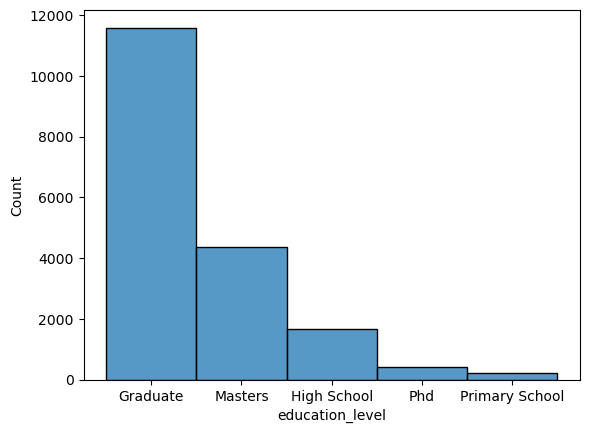

In [30]:
# Creating another histogram

sns.histplot(df['education_level']);

#### Major Discipline

In [31]:
df['major_discipline'].isna().sum()

np.int64(2064)

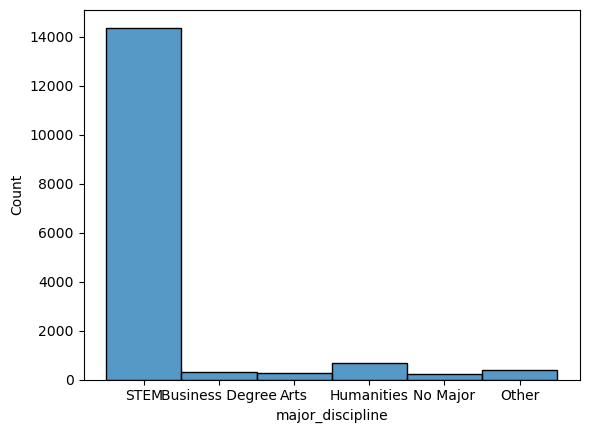

In [32]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['major_discipline']);

Again, based on the distribution and how many missing values there are I am going to impute by the statistics of the values.

In [33]:
# Get distribution of existing values
probabilities = df['major_discipline'].value_counts(normalize=True)
print(probabilities)

# Fill missing values based on those probabilities
df.loc[df['major_discipline'].isna(), 'major_discipline'] = np.random.choice(
    probabilities.index,
    size=df['major_discipline'].isna().sum(),
    p=probabilities.values)

df['major_discipline'].value_counts(normalize=True)

major_discipline
STEM               0.886347
Humanities         0.041009
Other              0.023372
Business Degree    0.020104
Arts               0.015540
No Major           0.013629
Name: proportion, dtype: float64


major_discipline
STEM               0.886433
Humanities         0.042013
Other              0.023414
Business Degree    0.019530
Arts               0.015208
No Major           0.013403
Name: proportion, dtype: float64

In [34]:
df['major_discipline'].isna().sum()

np.int64(0)

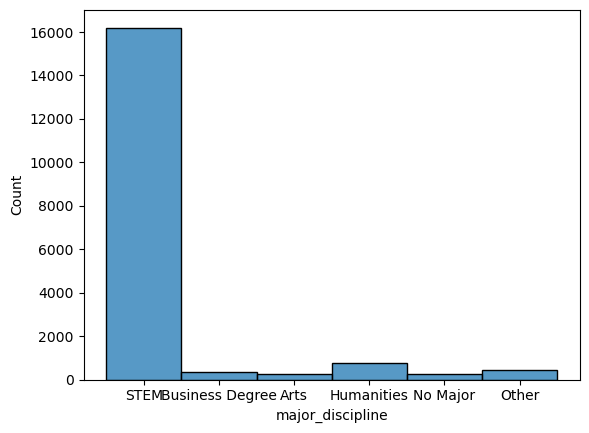

In [35]:
# Creating another histogram

sns.histplot(df['major_discipline']);

#### Experience

In [36]:
df['experience'].isna().sum()

np.int64(33)

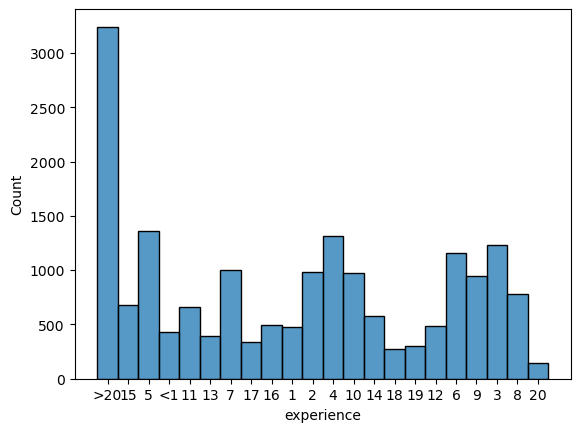

In [37]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['experience']);

Since there are only 33 missing values, I am just going to impute by the mode for simplicity.

In [38]:
df.experience.mode()

0    >20
Name: experience, dtype: object

In [39]:
# This command will find any missing values in the NumberOfFollowups section and replace with the mode.

df.loc[df.experience.isnull(), 'experience'] = df.experience.mode()[0]

In [40]:
df['experience'].isna().sum()

np.int64(0)

#### Company Size

In [41]:
df['company_size'].isna().sum()

np.int64(5095)

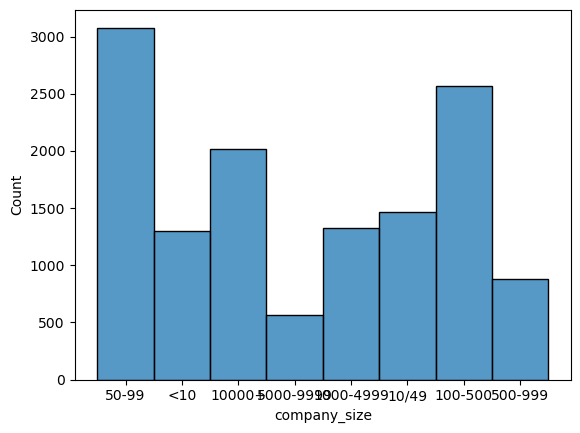

In [42]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['company_size']);

Again with this category having roughly 5000 missing values, I am going to impute using statistics.

In [43]:
# Get distribution of existing values
probabilities = df['company_size'].value_counts(normalize=True)
print(probabilities)

# Fill missing values based on those probabilities
df.loc[df['company_size'].isna(), 'company_size'] = np.random.choice(
    probabilities.index,
    size=df['company_size'].isna().sum(),
    p=probabilities.values)

df['company_size'].value_counts(normalize=True)

company_size
50-99        0.233447
100-500      0.194615
10000+       0.152825
10/49        0.110959
1000-4999    0.100493
<10          0.098597
500-999      0.066439
5000-9999    0.042624
Name: proportion, dtype: float64


company_size
50-99        0.231291
100-500      0.196882
10000+       0.153392
10/49        0.110175
1000-4999    0.101805
<10          0.099398
500-999      0.064114
5000-9999    0.042943
Name: proportion, dtype: float64

In [44]:
df['company_size'].isna().sum()

np.int64(0)

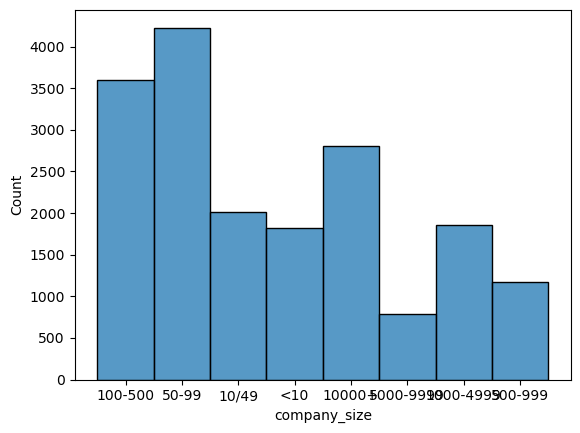

In [45]:
# Doing another check of the histogram

sns.histplot(df['company_size']);

#### Company Type

In [46]:
df['company_type'].isna().sum()

np.int64(5290)

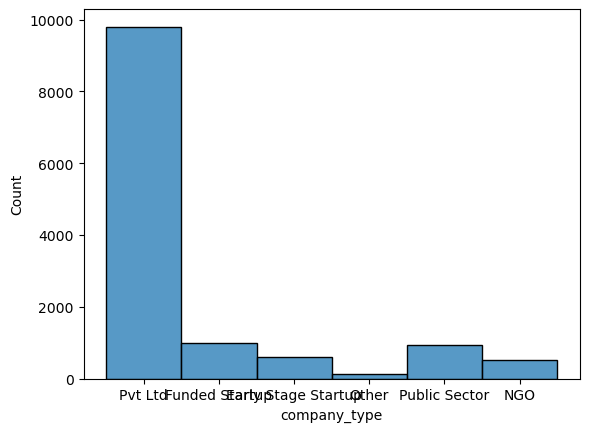

In [47]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['company_type']);

Once again with this category having roughly 5000 missing values, I am going to impute using statistics.

In [48]:
# Get distribution of existing values
probabilities = df['company_type'].value_counts(normalize=True)
print(probabilities)

# Fill missing values based on those probabilities
df.loc[df['company_type'].isna(), 'company_type'] = np.random.choice(
    probabilities.index,
    size=df['company_type'].isna().sum(),
    p=probabilities.values)

df['company_type'].value_counts(normalize=True)

company_type
Pvt Ltd                0.754426
Funded Startup         0.076905
Public Sector          0.073287
Early Stage Startup    0.046112
NGO                    0.040031
Other                  0.009238
Name: proportion, dtype: float64


company_type
Pvt Ltd                0.753611
Funded Startup         0.076477
Public Sector          0.073961
Early Stage Startup    0.046554
NGO                    0.039989
Other                  0.009409
Name: proportion, dtype: float64

In [49]:
df['company_type'].isna().sum()

np.int64(0)

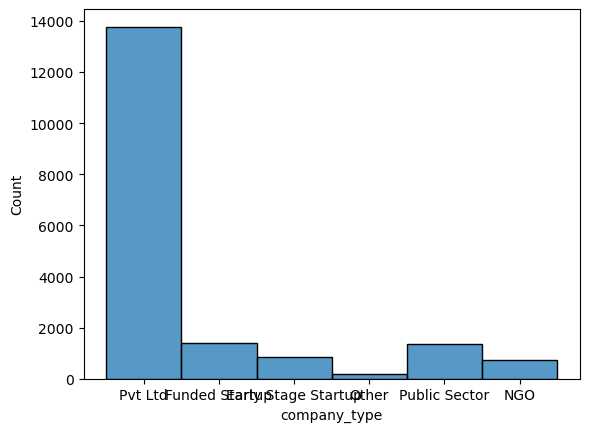

In [50]:
# Another check on the histogram

sns.histplot(df['company_type']);

#### Last New Job

In [51]:
df['last_new_job'].isna().sum()

np.int64(228)

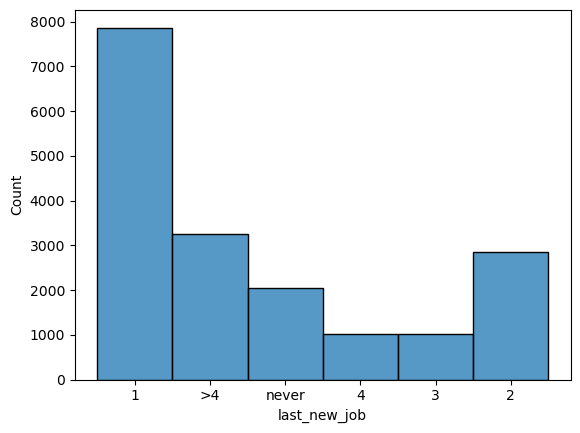

In [52]:
# Now, we need to decide how to impute the data. We have decided that if the data is skewed then we should use the median and if there is standard distribution we should use the mean.

sns.histplot(df['last_new_job']);

I am going to impute by the statistics here.

In [53]:
# Get distribution of existing values
probabilities = df['last_new_job'].value_counts(normalize=True)
print(probabilities)

# Fill missing values based on those probabilities
df.loc[df['last_new_job'].isna(), 'last_new_job'] = np.random.choice(
    probabilities.index,
    size=df['last_new_job'].isna().sum(),
    p=probabilities.values)

df['last_new_job'].value_counts(normalize=True)

last_new_job
1        0.435852
>4       0.180368
2        0.158210
never    0.112896
4        0.056503
3        0.056171
Name: proportion, dtype: float64


last_new_job
1        0.434956
>4       0.180963
2        0.158260
never    0.113129
4        0.056619
3        0.056072
Name: proportion, dtype: float64

In [54]:
df['last_new_job'].isna().sum()

np.int64(0)

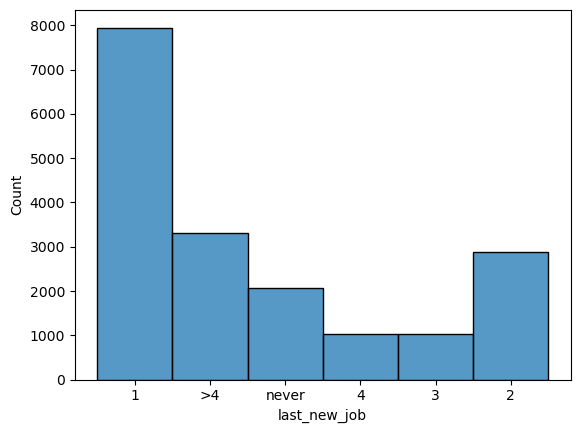

In [55]:
# Checking the histogram again

sns.histplot(df['last_new_job']);

#### Final Check

In [56]:
df.isna().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

We can see that we have corrected all null values.

### Outliers

In [57]:
# We will be checking the min and max values of all of the tables so we can then check the upper and lower bounds

df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,18280.0,16884.578282,9668.953713,1.000,8500.750,16980.50,25282.25,33380.000
city_development_index,18280.0,0.830497,0.122638,0.448,0.743,0.91,0.92,0.949
training_hours,18280.0,65.322429,60.045430,1.000,23.000,47.00,88.00,336.000
target,18280.0,0.247155,0.431370,0.000,0.000,0.00,0.00,1.000


In [58]:
# This function will check the tables in the dataframe to see the upper and lower bounds of all of them.

for item in df.select_dtypes(include='number').columns:
    Q1 = df[item].quantile(0.25)
    Q3 = df[item].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print("Lower bound of ", str(item) + ": " + str(lower))
    print("Upper bound of ", str(item) + ": " + str(upper))
    print("---------------------------------------")

Lower bound of  enrollee_id: -16671.5
Upper bound of  enrollee_id: 50454.5
---------------------------------------
Lower bound of  city_development_index: 0.4774999999999999
Upper bound of  city_development_index: 1.1855000000000002
---------------------------------------
Lower bound of  training_hours: -74.5
Upper bound of  training_hours: 185.5
---------------------------------------
Lower bound of  target: 0.0
Upper bound of  target: 0.0
---------------------------------------


training_hours has outliers in its maximum values. I am going to check whether this appears to be realistic or not.

#### Training Hours

<Axes: ylabel='training_hours'>

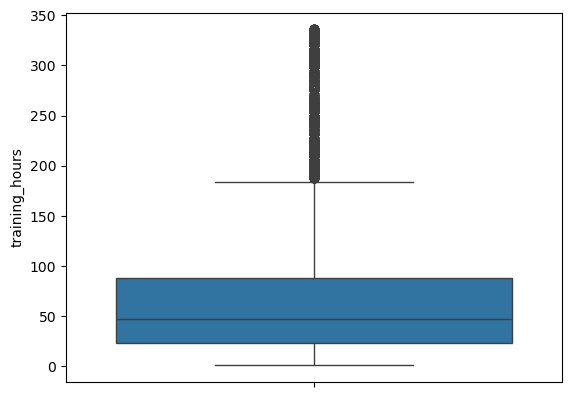

In [59]:
# We are going to begin by creating a boxplot so we can see if values need to be imputed.

sns.boxplot(data=df, y='training_hours')

Since there appears to be consistent values between the upper bound (185) and the max (336) I am going to leave this information in the data.

### Duplicates

Again, as I mentioned before enrollee_id seems to be a unique identifier. We will not be able to check for duplicates until this is removed. I will be removing this now.

In [60]:
df = df.drop(['enrollee_id'], axis=1)

In [61]:
# Now we can check again for duplicate values

df.duplicated().sum()

np.int64(52)

We can see that through all of my data preprocessing there were 56 duplicate values created, therefore we can now remove these.

In [62]:
df = df.drop_duplicates()

# Now we can check again for duplicate values

df.duplicated().sum()

np.int64(0)

### Observations

In [63]:
df.shape

(18228, 13)

Comparing this to the initial shape (19158, 14) we can see that we removed roughly 1100 entries. This is significant, but with all of the imputing we did I feel like this was the right way to go to ensure the data within our dataframe is relatively well taken care of and clean. We are now able to move on to EDA.

## EDA

### User Defined Functions

In [64]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [65]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
        legend=False
)

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [66]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [67]:
### function to plot distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18228 entries, 0 to 19156
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    18228 non-null  object 
 1   city_development_index  18228 non-null  float64
 2   gender                  18228 non-null  object 
 3   relevent_experience     18228 non-null  object 
 4   enrolled_university     18228 non-null  object 
 5   education_level         18228 non-null  object 
 6   major_discipline        18228 non-null  object 
 7   experience              18228 non-null  object 
 8   company_size            18228 non-null  object 
 9   company_type            18228 non-null  object 
 10  last_new_job            18228 non-null  object 
 11  training_hours          18228 non-null  int64  
 12  target                  18228 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 1.9+ MB


In [69]:
df.head(5)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,100-500,Pvt Ltd,1,36,1.0
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,city_21,0.624,Female,No relevent experience,Full time course,Graduate,STEM,5,100-500,Pvt Ltd,never,83,0.0
3,city_115,0.789,Female,No relevent experience,no_enrollment,Graduate,Business Degree,<1,100-500,Pvt Ltd,never,52,1.0
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


#### Gender

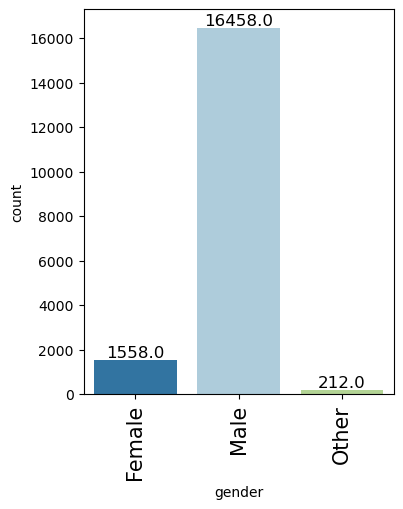

In [70]:
labeled_barplot(df, 'gender')

Observations:

This barplot shows that the majority of job candidates within this dataset are males.

#### City 

<Axes: ylabel='city'>

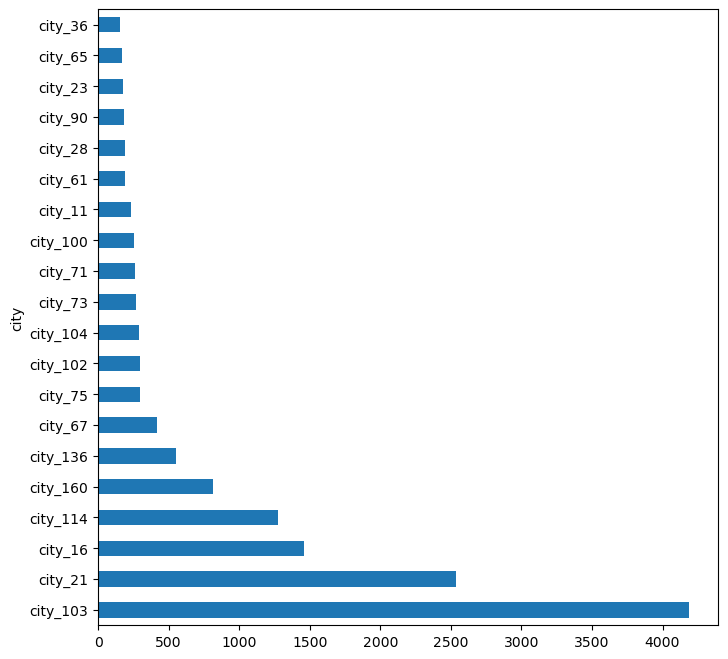

In [71]:
df['city'].value_counts().head(20).plot(kind='barh', figsize=(8, 8))

Observations:

I used a bar chart to show the first 20 features of the dataframe sorted. This makes this data more readable. What this shows is that city 103 contains the most job applications.

#### Relevent Experience

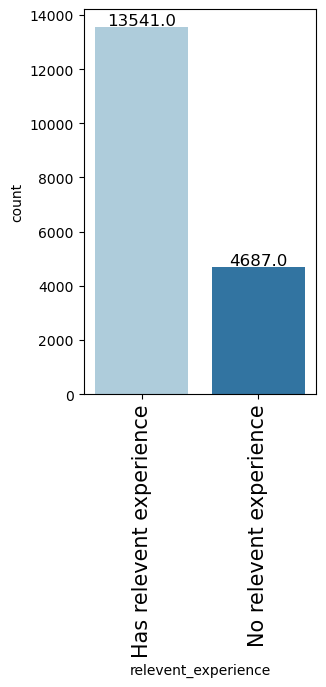

In [72]:
labeled_barplot(df, 'relevent_experience')

Observations:

This barplot shows that the majority of applicants for this position have relevent experience

#### Enrolled University

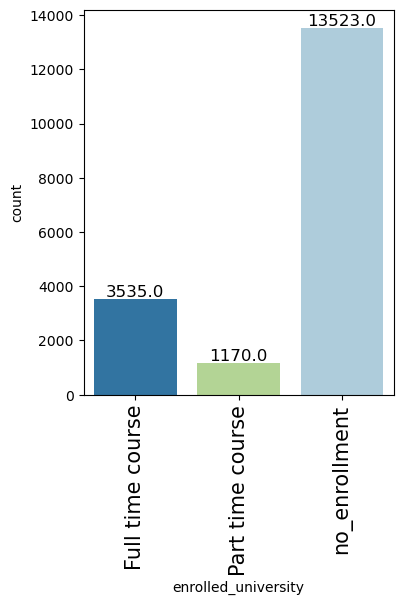

In [73]:
labeled_barplot(df, 'enrolled_university')

Observations:

The majority of the applicants in this dataframe are not enrolled in university.

#### Education Level

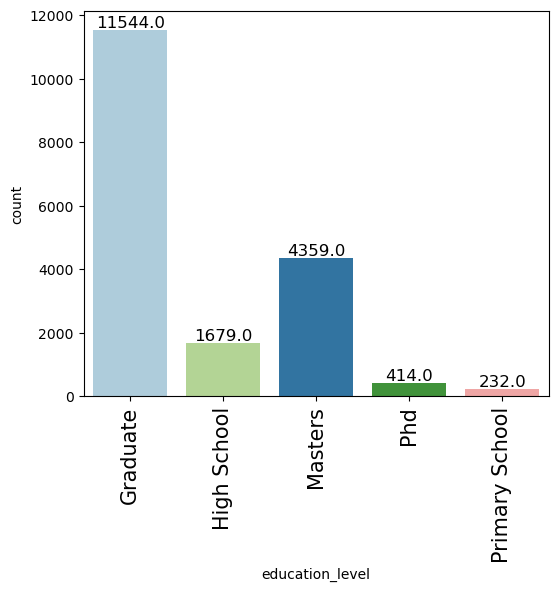

In [74]:
labeled_barplot(df, 'education_level')

Observations:

While majority of applicants to the job may not be enrolled in university, they are also majority graduates. 

#### Major Discipline

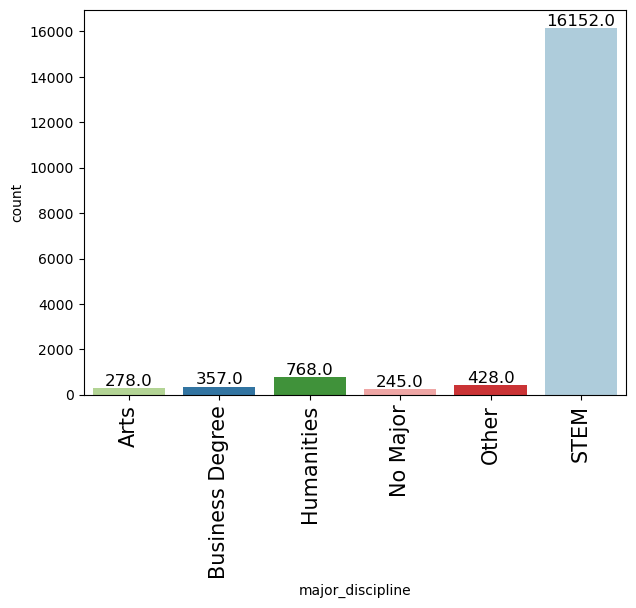

In [75]:
labeled_barplot(df, 'major_discipline')

Observations:

The majority of applicants to this job are STEM majors.

#### Experience

<Axes: xlabel='experience'>

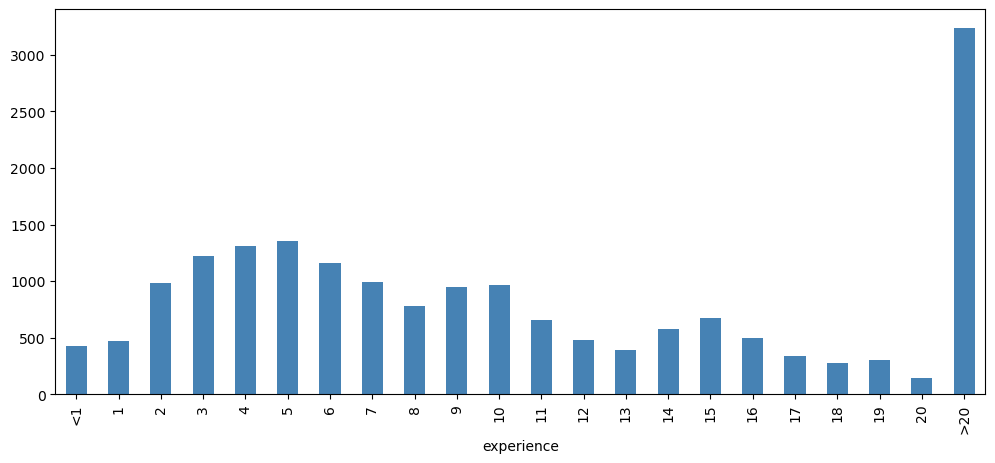

In [76]:
order = ['<1', '1','2','3','4','5','6','7','8','9','10',
         '11','12','13','14','15','16','17','18','19','20','>20']
counts = df['experience'].value_counts().reindex(order)
counts.plot(kind='bar', color='steelblue', figsize=(12, 5))

Observations:

There are a few significant humps where people are applying for this job. around the 5 year range, 10 year range, 15 year range, and more than 20 years. The majority of applicants, however, applied with more than 20 years of experience.

#### Company Size

<Axes: xlabel='company_size'>

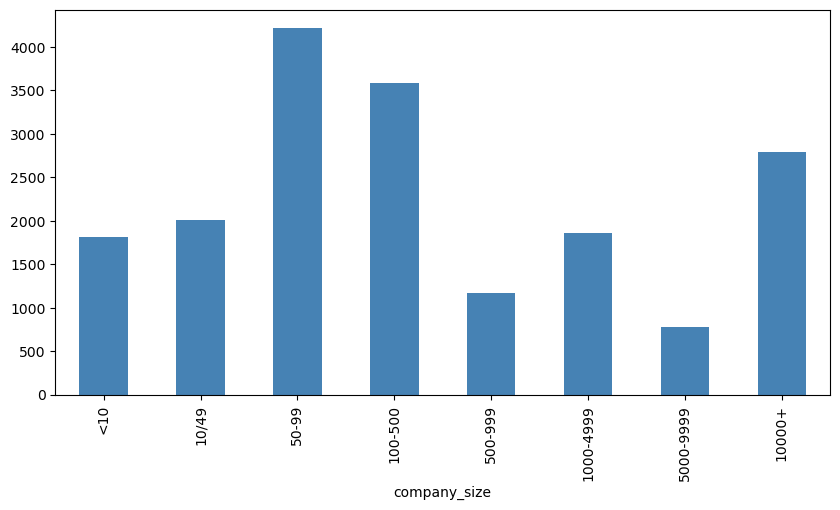

In [77]:
order = ['<10', '10/49', '50-99', '100-500', '500-999', 
         '1000-4999', '5000-9999', '10000+']
counts = df['company_size'].value_counts().reindex(order)
counts.plot(kind='bar', color='steelblue', figsize=(10, 5))

Observations:

The majority of applicants for this position come from small companies with 50-99 current coworkers.

#### Company Type

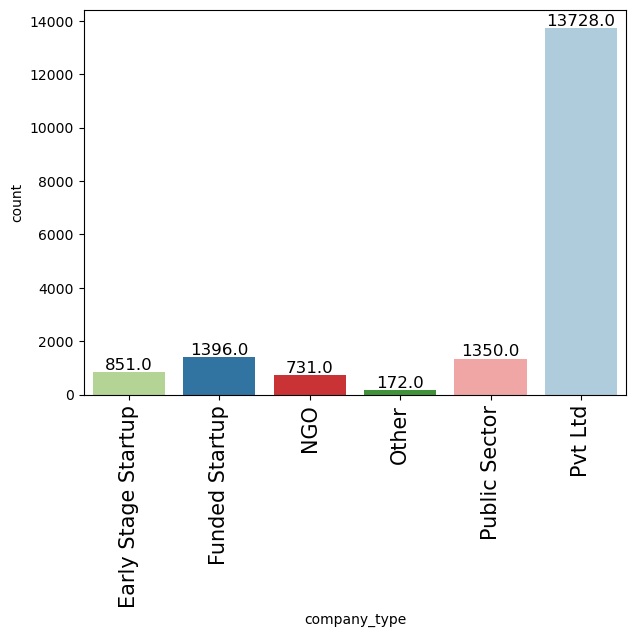

In [78]:
labeled_barplot(df, 'company_type')

Observations:

The majority of people applying for this job come from private companies.

#### Last New Job

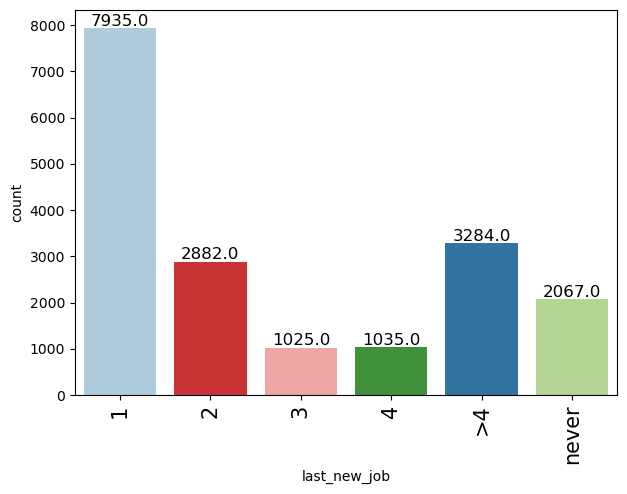

In [79]:
labeled_barplot(df, 'last_new_job')

Observations:

The majority of people applying for this job have just gotten a new job a year ago, implying they may be a bit of a flight risk.

#### Training Hours

In [80]:
df.training_hours.describe()

count    18228.000000
mean        65.409919
std         60.090458
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

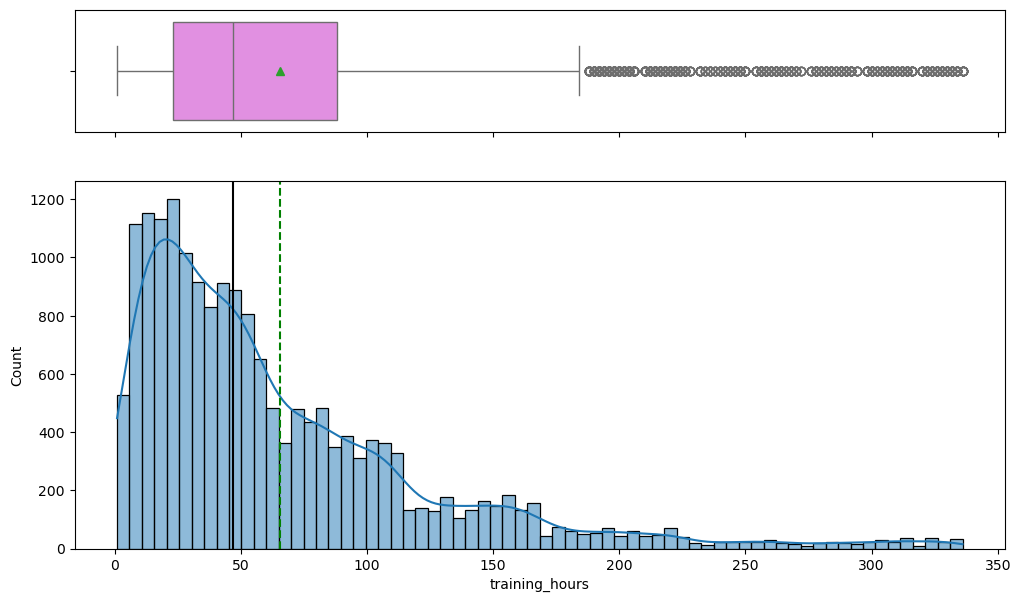

In [81]:
histogram_boxplot(df, 'training_hours',kde=True)

Observations:

While the average amount of time to be trained appears to hover around the 45-50 hour range, there are a large amount of applicants that seem to need a bit more training.

#### City Development Index

In [82]:
df.city_development_index.describe()

count    18228.000000
mean         0.830342
std          0.122675
min          0.448000
25%          0.743000
50%          0.910000
75%          0.920000
max          0.949000
Name: city_development_index, dtype: float64

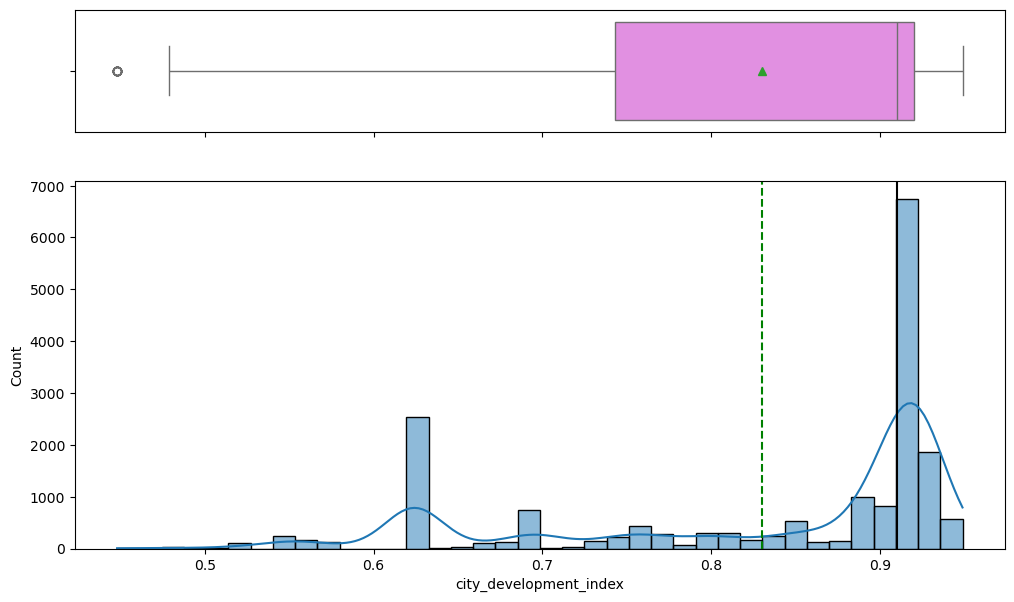

In [83]:
histogram_boxplot(df, 'city_development_index',kde=True)

Observations:

This chart appears to show the city data but in a standardized set. I will have to do more investigation on this before I can learn more. 

### Bivariate Analysis

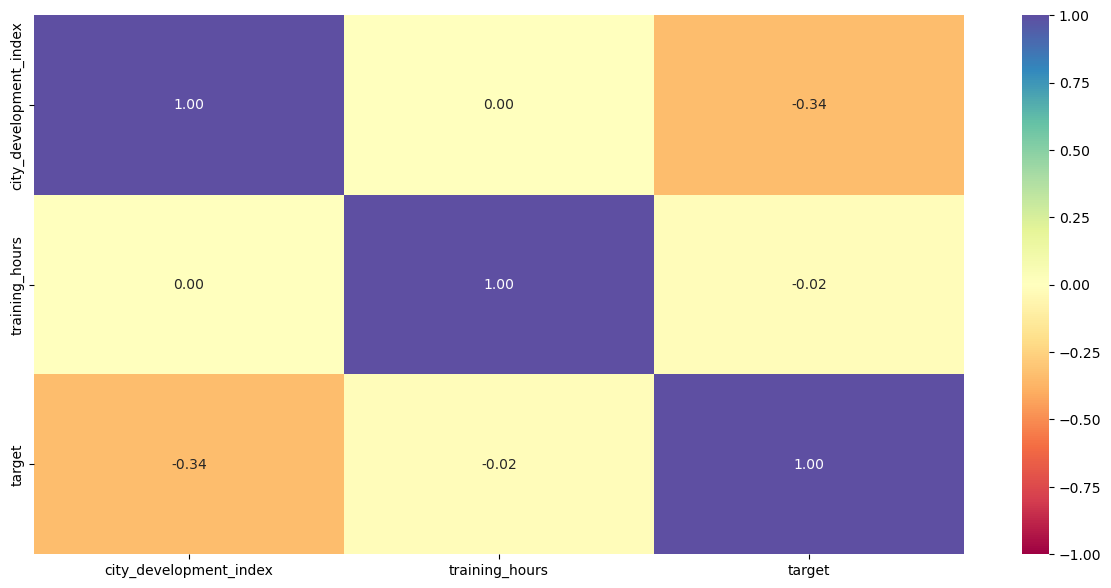

In [84]:
# Creating a heatmap.

plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Observations:

Considering the majority of our data is currently categorical, there is no surprise that the heatmap does not appear to show much. We can learn though that the training hours dataset seems to have very low correlation to the target, and it may need to be removed later. Because we cannot see categorical features, I asked generative AI to help me generate a way to see high and low correlations with the target, this plot can be seen below. 

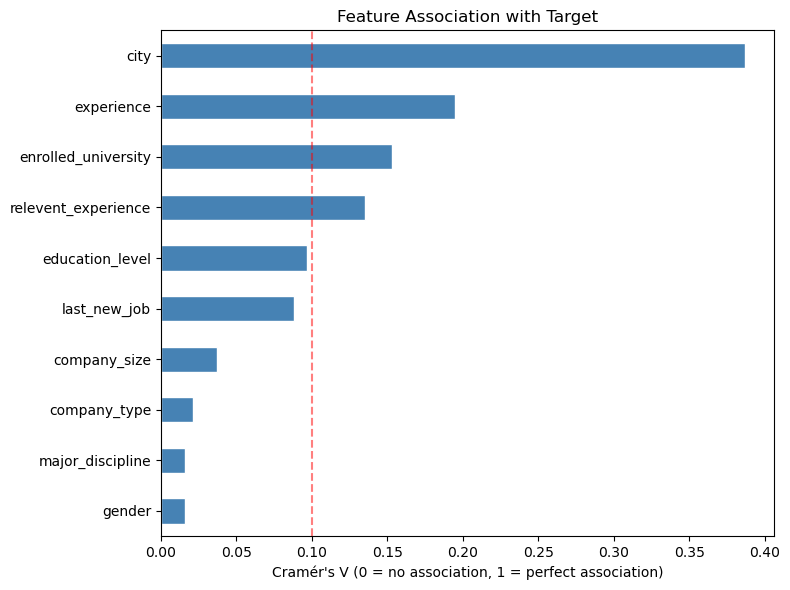

In [85]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Compute for all categorical features
cat_features = df.select_dtypes(include='object').columns.tolist()
target = 'target'

scores = {col: cramers_v(df[col], df[target]) 
          for col in cat_features if col != target}

# Plot
pd.Series(scores).sort_values().plot(
    kind='barh', figsize=(8, 6), color='steelblue', edgecolor='white'
)
plt.xlabel("Cramér's V (0 = no association, 1 = perfect association)")
plt.title("Feature Association with Target")
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Weak threshold')
plt.tight_layout()

Observations:

Using this chart, I have decided that later in the feature engineering process I may consider removing features like company_size, company_type, and major_discipline.

#### Gender and Target

<Axes: xlabel='gender', ylabel='count'>

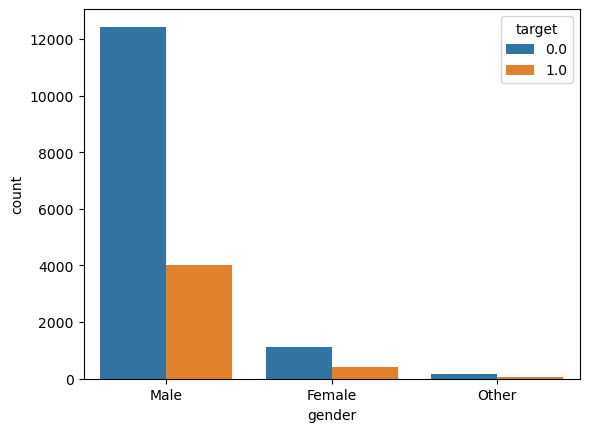

In [86]:
sns.countplot(x='gender', hue='target', data=df)

Observations:

The percent of individuals who were hired appear to have been hired equally despite their gender. 

#### City and Target

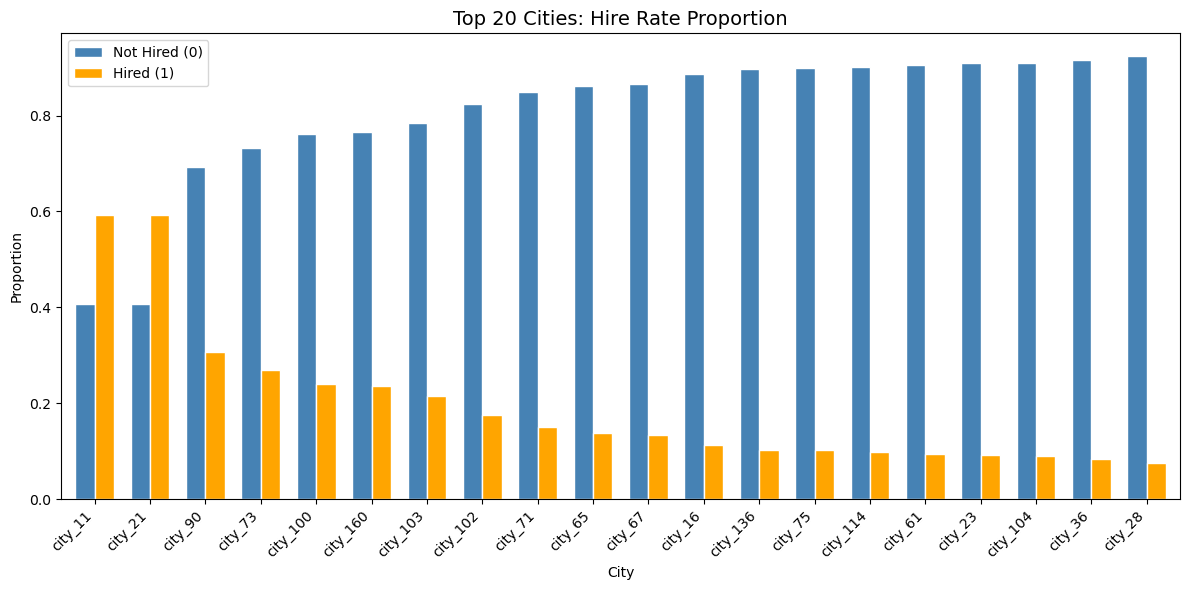

In [87]:
top_cities = df['city'].value_counts().head(20).index
subset = df[df['city'].isin(top_cities)].copy()

# Normalize to proportions within each city
city_target = pd.crosstab(subset['city'], subset['target'], normalize='index')

# Sort by hire rate (target=1)
city_target = city_target.sort_values(1.0, ascending=False)

city_target.plot(
    kind='bar', 
    figsize=(12, 6), 
    color={0.0: 'steelblue', 1.0: 'orange'},
    edgecolor='white',
    width=0.7
)

plt.title('Top 20 Cities: Hire Rate Proportion', fontsize=14)
plt.xlabel('City')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(['Not Hired (0)', 'Hired (1)'])
plt.tight_layout()
plt.show()

Observations:

This shows the data sorted among the top 20 hired cities and it is clear that the most people hired came from city 11 and city 21, after that it switched from more people hired than not to more people not hired than hired. 

#### Relevent Experience and Target

<Axes: xlabel='relevent_experience', ylabel='count'>

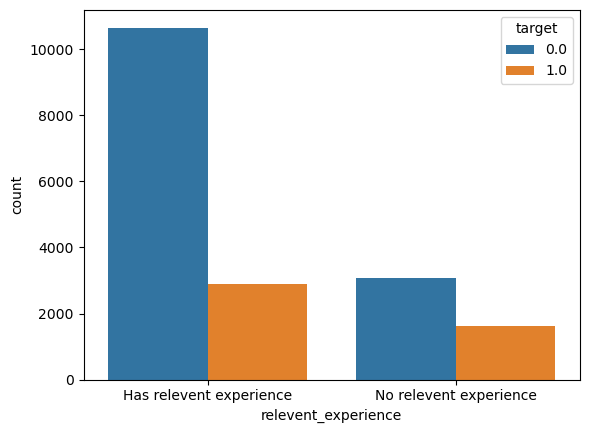

In [88]:
sns.countplot(x='relevent_experience', hue='target', data=df)

Observations:

While more people with relevent experience did apply to the job, it does not seem like this expressly led to more people being hired. 

#### Enrolled University and Target

<Axes: xlabel='enrolled_university', ylabel='count'>

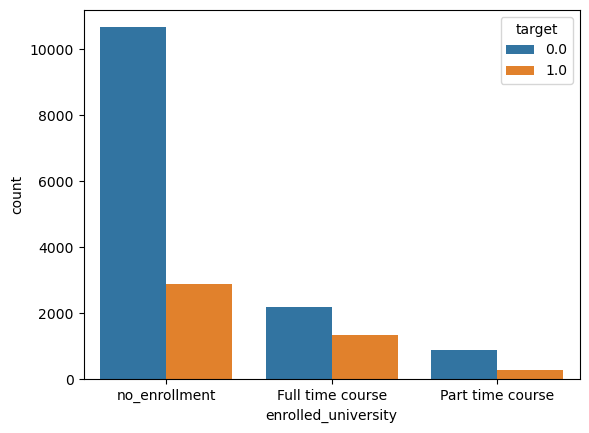

In [89]:
sns.countplot(x='enrolled_university', hue='target', data=df)

Observations:

While the most number of people who were hired were not enrolled in college, this seems to be a bit misleading considering these people were likely not college dropouts, highschool graduates, or any other form of not being enrolled, but rather an indicator of having graduated. 

#### Education Level and Target

<Axes: xlabel='education_level', ylabel='count'>

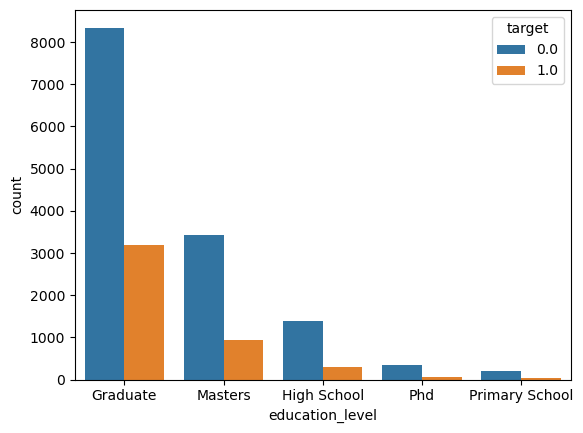

In [90]:
sns.countplot(x='education_level', hue='target', data=df)

Observations:

This appears to correlate with what I thought about Enrolled University. Due to that, I am going to make a bivariate analysis between these two figures. 

#### Education Level and Enrolled University

<Axes: xlabel='education_level', ylabel='count'>

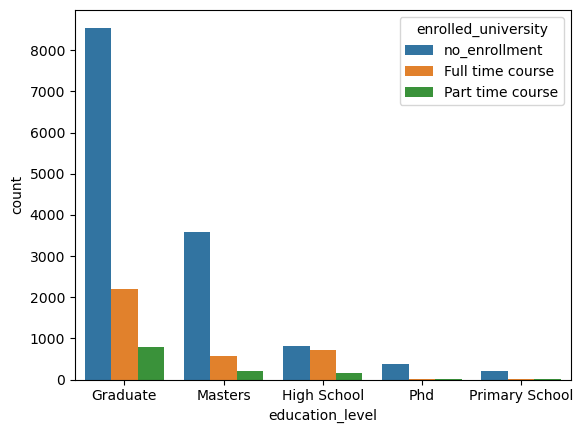

In [91]:
sns.countplot(x='education_level', hue='enrolled_university', data=df)

Observations:

This appears to line up with what I had been thinking with no enrollment meaning graduate. Due to this, we may end up changing or combining these features later. 

#### Major Discipline and Target

<Axes: xlabel='major_discipline', ylabel='count'>

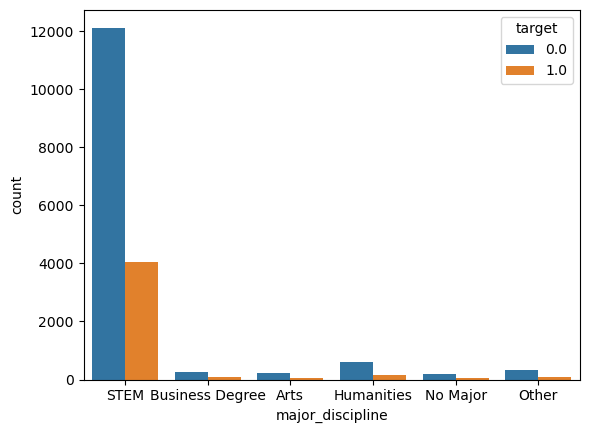

In [92]:
sns.countplot(x='major_discipline', hue='target', data=df)

Observations:

While some people were hired outside of the STEM major, majority of people who were hired had a STEM degree. 

#### Experience and Target

<Axes: xlabel='experience', ylabel='count'>

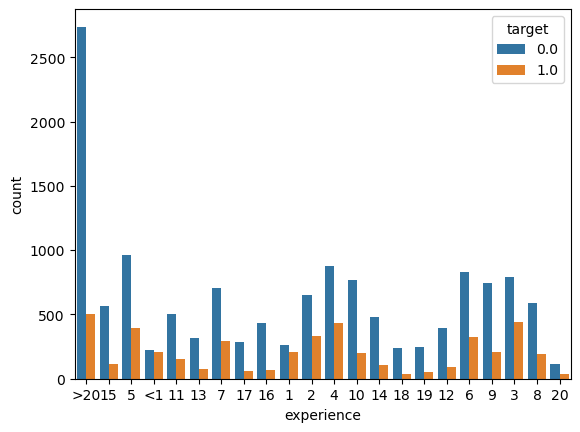

In [93]:
sns.countplot(x='experience', hue='target', data=df)

Observations:

While the plot is a bit hard to read, it shows that people are hired relatively fairly due to experience. What this really shows is that we will need to engineer this data come feature engineering.

#### Company Size and Target

<Axes: xlabel='company_size', ylabel='count'>

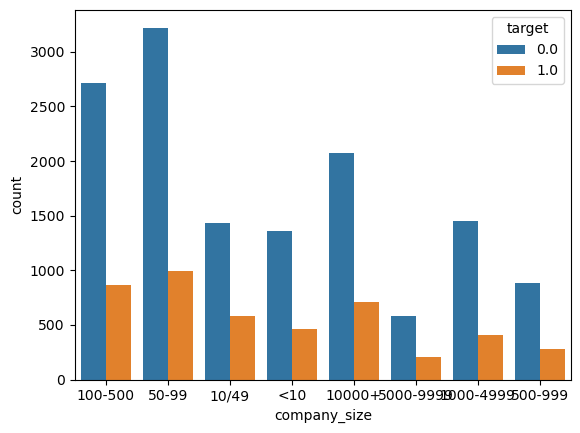

In [94]:
sns.countplot(x='company_size', hue='target', data=df)

Observations:

This plot seems to show that people appear to be hired relatively equally across all company sizes.

#### Company Type and Target

<Axes: xlabel='company_type', ylabel='count'>

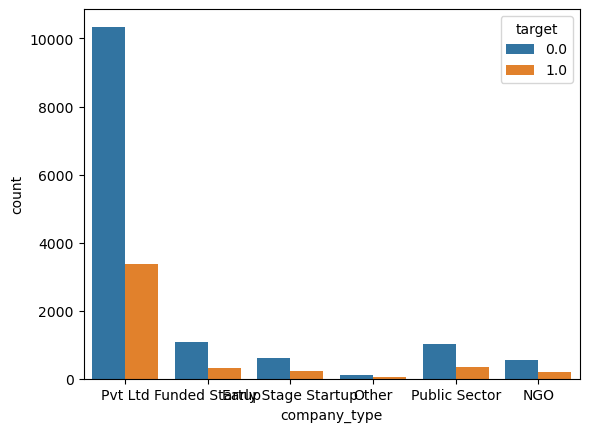

In [95]:
sns.countplot(x='company_type', hue='target', data=df)

Observations:

Again, people appear to be hired relatively equally despite the company type.

#### Last New Job and Target

<Axes: xlabel='last_new_job', ylabel='count'>

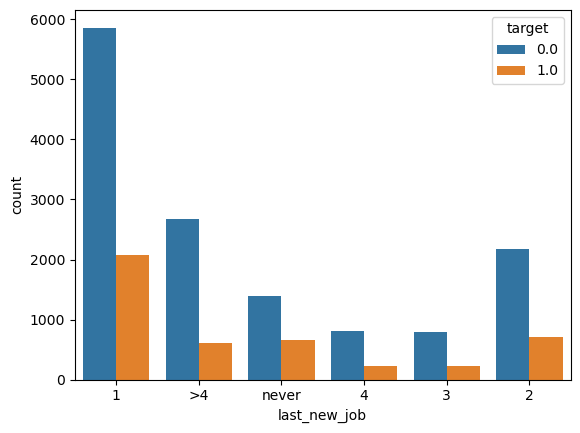

In [96]:
sns.countplot(x='last_new_job', hue='target', data=df)

Observations:

This job appears to have a slight preference to people who have never had a job before or are looking to change jobs within 1 to 2 years.

#### Training Hours and Target

<Axes: xlabel='target', ylabel='training_hours'>

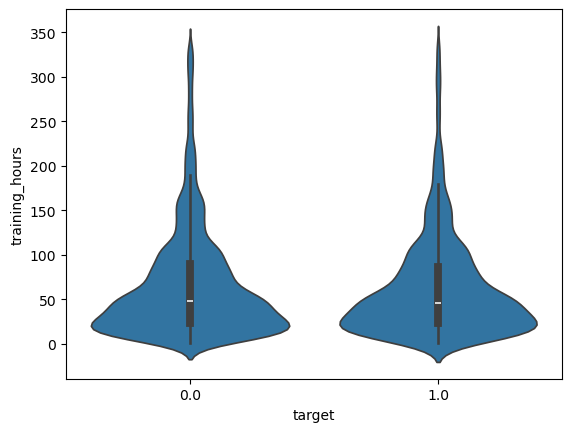

In [97]:
sns.violinplot(x=df["target"], y=df["training_hours"])

Observations:

This violin plot seems to show that there is very low correlation between how many training hours a person requires and whether they will be hired. 

#### City Development Index and Target

<Axes: xlabel='target', ylabel='city_development_index'>

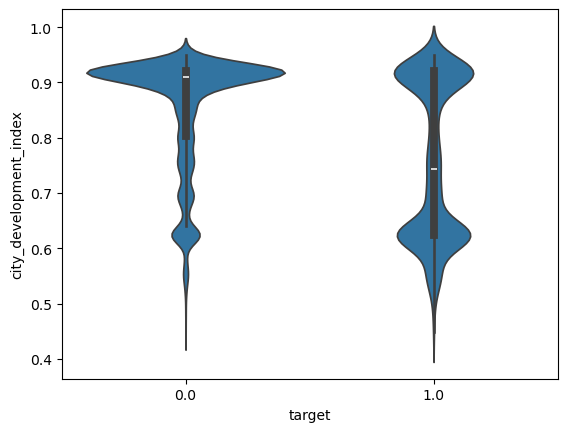

In [98]:
sns.violinplot(x=df["target"], y=df["city_development_index"])

Observations:

This violin plot seems to show that there is a correlation between a certain area (rougly 9.2) and not being hired and two other areas (roughly 0.6 and 0.93) and being hired

### Observations

Through my EDA I have come to a couple of conclusions.

Due to low correlation, the following features need to be dropped:
- Training Hours
- Company Size
- Company Type

On top of this, I was able to see that the most likely hirees for the job seem to be from city 11 or 21, have relevent experience, and be graduated in a relevant field. 

I have also decided that I plan to combine the features Enrolled University and Education Level to get a better feature. 

In [99]:
df = df.drop(['training_hours'], axis=1)

In [100]:
df = df.drop(['company_size'], axis=1)

In [101]:
df = df.drop(['company_type'], axis=1)

I will go about combining features during feature engineering.

In [102]:
# Now that we have dropped features I am going to make a copy so we can compare if we need to then show the head. 

dfCOPY = df

df.head(5)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,target
0,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,1,1.0
1,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,>4,0.0
2,city_21,0.624,Female,No relevent experience,Full time course,Graduate,STEM,5,never,0.0
3,city_115,0.789,Female,No relevent experience,no_enrollment,Graduate,Business Degree,<1,never,1.0
4,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,4,0.0


## Feature Engineering

### Gender

I am going to begin by one-hot encoding gender, since it has only 3 categories. 

In [103]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=int)

In [104]:
df.head(5)

,city,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,target,gender_Male,gender_Other
0,city_103,0.920,Has relevent experience,no_enrollment,Graduate,STEM,>20,1,1.0,1,0
1,city_40,0.776,No relevent experience,no_enrollment,Graduate,STEM,15,>4,0.0,1,0
2,city_21,0.624,No relevent experience,Full time course,Graduate,STEM,5,never,0.0,0,0
3,city_115,0.789,No relevent experience,no_enrollment,Graduate,Business Degree,<1,never,1.0,0,0
4,city_162,0.767,Has relevent experience,no_enrollment,Masters,STEM,>20,4,0.0,1,0


### City

For city I am going to scale it so that each city has a percentage to compare to the city number using a function. I am then going to compare this to city development index to see any similarities or differences.

In [105]:
# Calculate hire rate per city
city_target_rate = df.groupby('city')['target'].mean()

# Map it back as a new feature
df['city'] = df['city'].map(city_target_rate)

In [106]:
df.head(5)

,city,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,target,gender_Male,gender_Other
0,0.215054,0.920,Has relevent experience,no_enrollment,Graduate,STEM,>20,1,1.0,1,0
1,0.138462,0.776,No relevent experience,no_enrollment,Graduate,STEM,15,>4,0.0,1,0
2,0.592359,0.624,No relevent experience,Full time course,Graduate,STEM,5,never,0.0,0,0
3,0.388889,0.789,No relevent experience,no_enrollment,Graduate,Business Degree,<1,never,1.0,0,0
4,0.271186,0.767,Has relevent experience,no_enrollment,Masters,STEM,>20,4,0.0,1,0


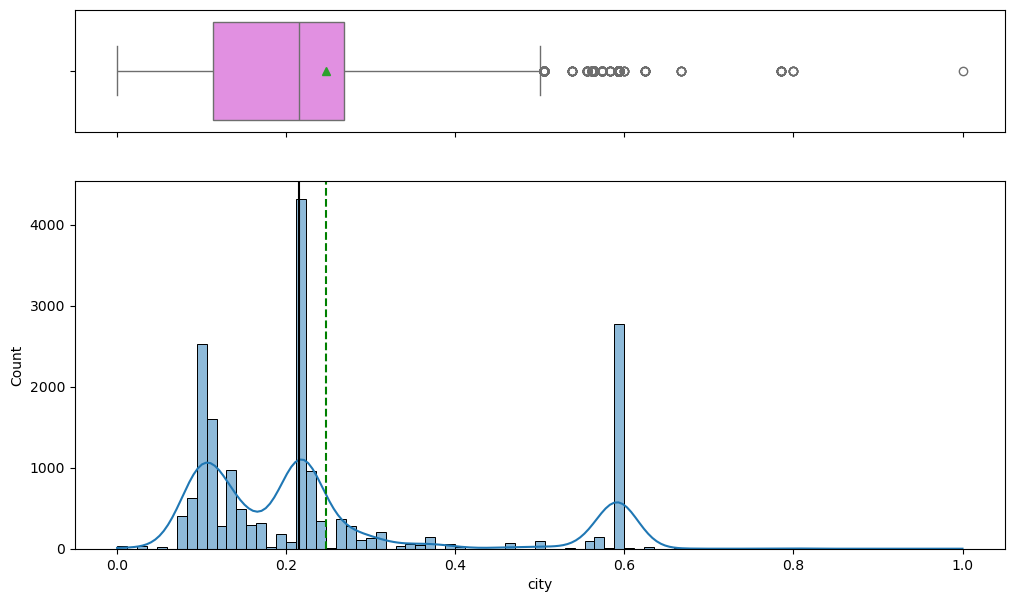

In [107]:
histogram_boxplot(df, 'city',kde=True)

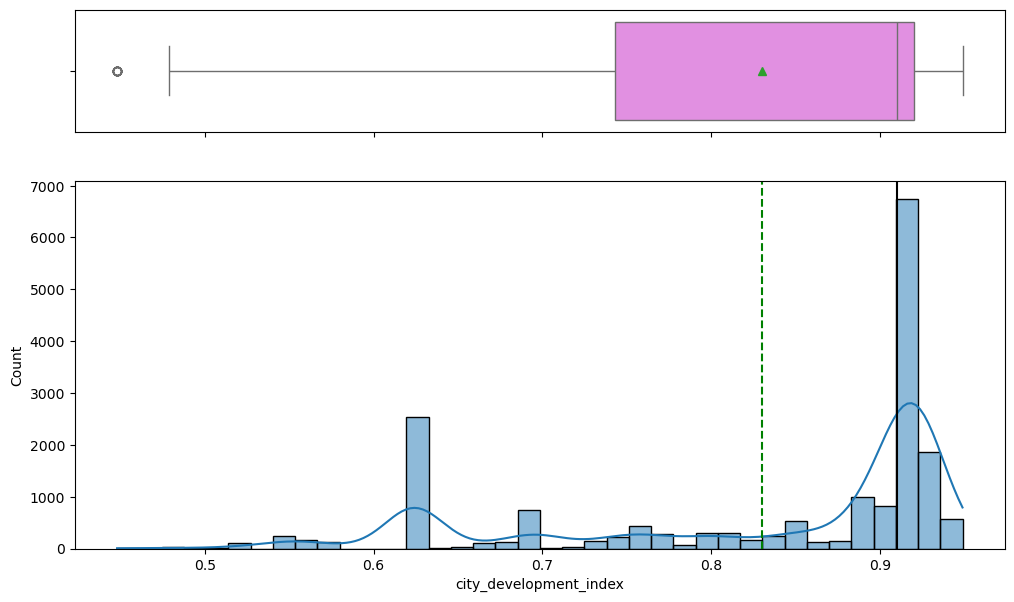

In [108]:
histogram_boxplot(df, 'city_development_index',kde=True)

<Axes: xlabel='city', ylabel='city_development_index'>

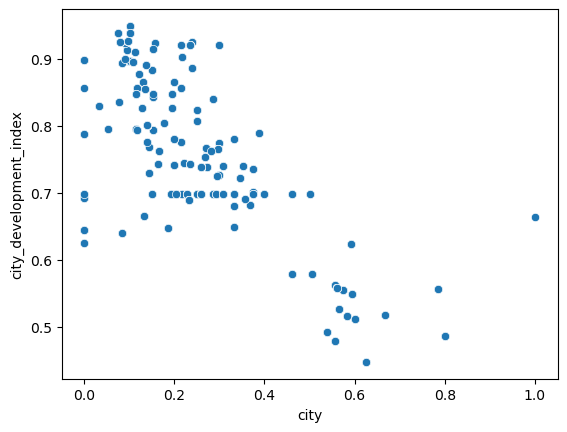

In [109]:
sns.scatterplot(x=df["city"], y=df["city_development_index"])

Observations:

After normalizing there appears to be a slight negative correlation between these two features. 

### Relevent Experience

Since relevent experience has only 2 features, I am going to one-hot encode these features. 

In [110]:
df = pd.get_dummies(df, columns=['relevent_experience'], drop_first=True, dtype=int)

In [111]:
df.head(5)

,city,city_development_index,enrolled_university,education_level,major_discipline,experience,last_new_job,target,gender_Male,gender_Other,relevent_experience_No relevent experience
0,0.215054,0.920,no_enrollment,Graduate,STEM,>20,1,1.0,1,0,0
1,0.138462,0.776,no_enrollment,Graduate,STEM,15,>4,0.0,1,0,1
2,0.592359,0.624,Full time course,Graduate,STEM,5,never,0.0,0,0,1
3,0.388889,0.789,no_enrollment,Graduate,Business Degree,<1,never,1.0,0,0,1
4,0.271186,0.767,no_enrollment,Masters,STEM,>20,4,0.0,1,0,0


### Education Level and Enrolled University

As previously discussed, I plan to combine these two features. I will do this by first making them one feature then deciding if the features can be combined more. 

In [112]:
df['education_level'] = df['education_level'].replace({
    'Primary School': 'Other',
    'Phd': 'Other'  # optional — depends on if PhD is meaningful for your target
})

df['enrolled_university'] = df['enrolled_university'].replace({
    'Full time course': 'enrolled',
    'Part time course': 'enrolled',
    'no_enrollment': 'not_enrolled'
})

df['education_enrollment'] = df['education_level'] + '_' + df['enrolled_university']

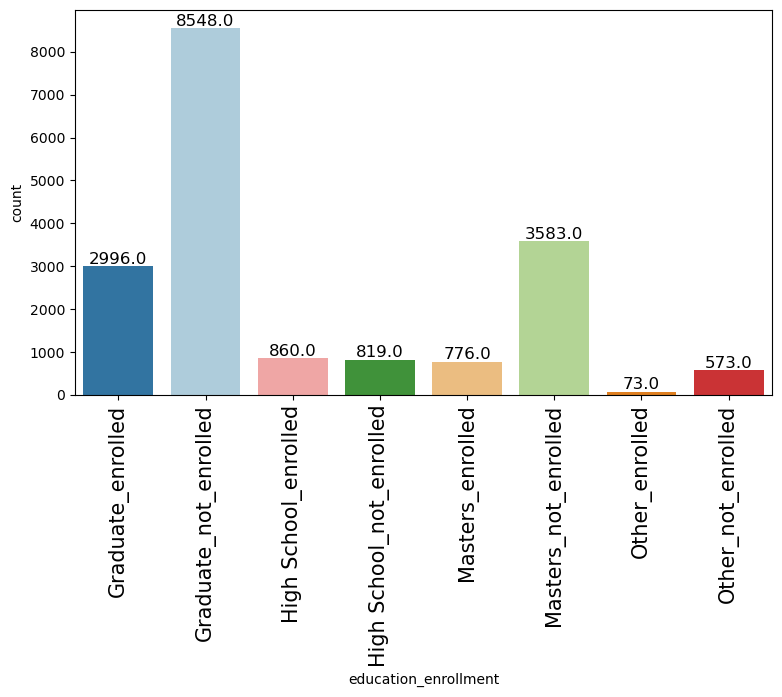

In [113]:
labeled_barplot(df, 'education_enrollment')

In [114]:
df = df.drop(['enrolled_university'], axis=1)
df = df.drop(['education_level'], axis=1)

Now that we have done all of this combining, I want to compare it to the original features to make sure that this is better than before.

In [115]:
print("Combined:", cramers_v(df['education_enrollment'], df['target']))
print("Education only:", cramers_v(dfCOPY['education_level'], df['target']))
print("Enrollment only:", cramers_v(dfCOPY['enrolled_university'], df['target']))

Combined: 0.17229256347160724
Education only: 0.0965632462159591
Enrollment only: 0.15309853119520594


We can clearly see now that the combined features have a better correlation with the target then either variable on their own. Now we are going to one-hot encode these features into the dataframe.

In [116]:
df = pd.get_dummies(df, columns=['education_enrollment'], drop_first=True, dtype=int)

In [117]:
df.head(5)

,city,city_development_index,major_discipline,experience,last_new_job,target,gender_Male,gender_Other,relevent_experience_No relevent experience,education_enrollment_Graduate_not_enrolled,education_enrollment_High School_enrolled,education_enrollment_High School_not_enrolled,education_enrollment_Masters_enrolled,education_enrollment_Masters_not_enrolled,education_enrollment_Other_enrolled,education_enrollment_Other_not_enrolled
0,0.215054,0.920,STEM,>20,1,1.0,1,0,0,1,0,0,0,0,0,0
1,0.138462,0.776,STEM,15,>4,0.0,1,0,1,1,0,0,0,0,0,0
2,0.592359,0.624,STEM,5,never,0.0,0,0,1,0,0,0,0,0,0,0
3,0.388889,0.789,Business Degree,<1,never,1.0,0,0,1,1,0,0,0,0,0,0
4,0.271186,0.767,STEM,>20,4,0.0,1,0,0,0,0,0,0,1,0,0


### Major Discipline

I am going to begin by looking into this feature to see if anything can be combined before one-hot encoding. 

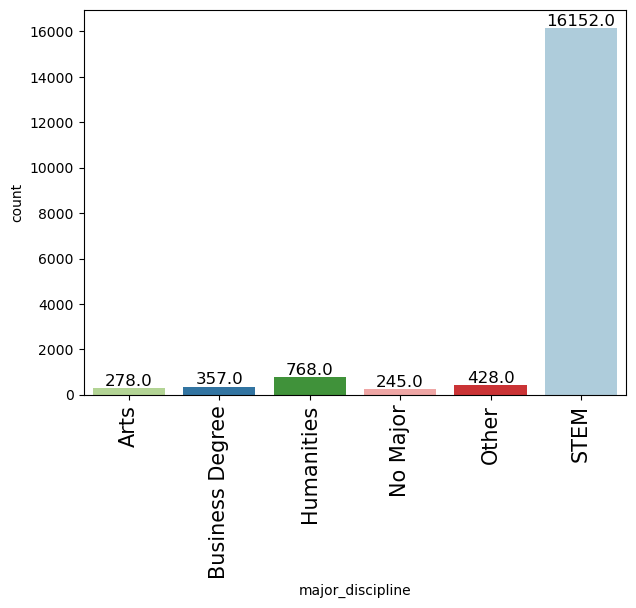

In [118]:
labeled_barplot(df, 'major_discipline')

In [119]:
# I am going to check how this feature relates to the target first

cramers_v(df['major_discipline'], df['target'])

np.float64(0.015907108169776547)

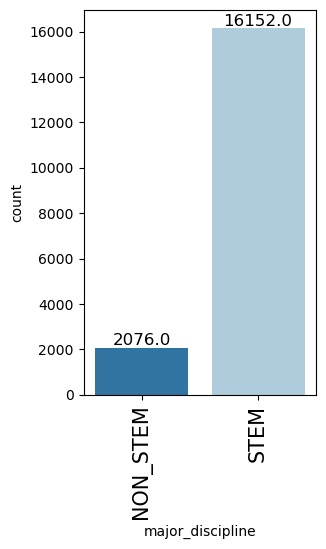

np.float64(0.012890047070749278)

In [120]:
# Using my 'copy' of the dataset I am going to test whether a STEM vs NON STEM dataset would increase the relation to the target

Group = ['Arts', 'Business Degree', 'Humanities', 'No Major', 'Other']
dfCOPY['major_discipline'] = dfCOPY['major_discipline'].replace(Group, 'NON_STEM')

labeled_barplot(dfCOPY, 'major_discipline')

cramers_v(dfCOPY['major_discipline'], df['target'])

This appeared to decrease the predictability on the model, due to this I am going just one-hot encode this feature.

In [121]:
df = pd.get_dummies(df, columns=['major_discipline'], drop_first=True, dtype=int)

### Experience

For this section I am planning on binning this feature before one-hot encoding it.

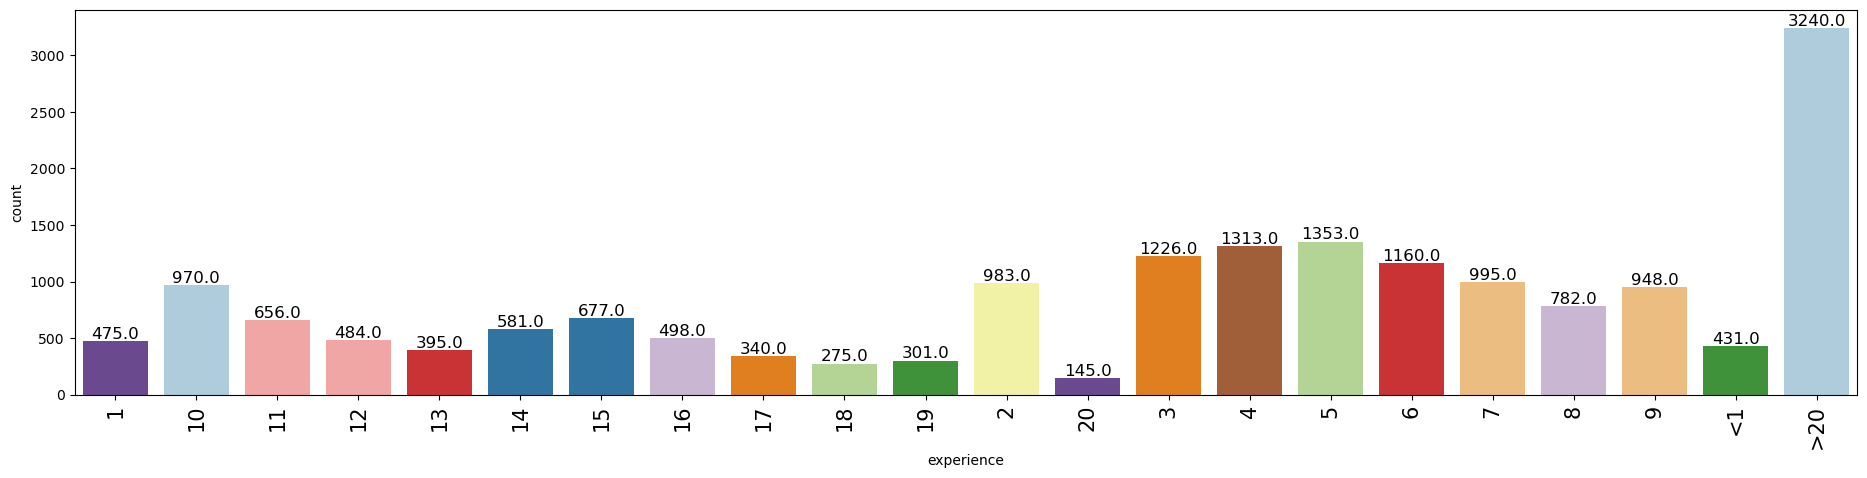

In [122]:
labeled_barplot(df, 'experience')

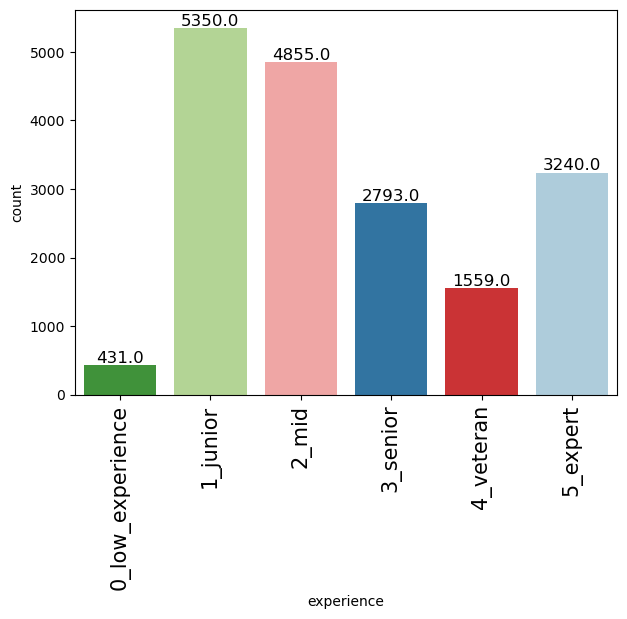

In [123]:
def bin_experience(x):
    if x in ['<1']:
        return '0_low_experience'        # <1 year
    elif x in ['1', '2', '3', '4', '5']:
        return '1_junior'       # 1-5 years
    elif x in ['6', '7', '8', '9', '10']:
        return '2_mid'          # 6-10 years
    elif x in ['11', '12', '13', '14', '15']:
        return '3_senior'       # 11-15 years
    elif x in ['16', '17', '18', '19', '20']:
        return '4_veteran'      # 16-20 years
    elif x == '>20':
        return '5_expert'       # 20+ years
    return 'unknown'

df['experience'] = df['experience'].apply(bin_experience)

labeled_barplot(df, 'experience')

Now that I have done this I am going to one-hot encode this data.

In [124]:
df = pd.get_dummies(df, columns=['experience'], drop_first=True, dtype=int)

In [125]:
df.head(5)

,city,city_development_index,last_new_job,target,gender_Male,gender_Other,relevent_experience_No relevent experience,education_enrollment_Graduate_not_enrolled,education_enrollment_High School_enrolled,education_enrollment_High School_not_enrolled,...,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,experience_1_junior,experience_2_mid,experience_3_senior,experience_4_veteran,experience_5_expert
0,0.215054,0.920,1,1.0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
1,0.138462,0.776,>4,0.0,1,0,1,1,0,0,...,0,0,0,0,1,0,0,1,0,0
2,0.592359,0.624,never,0.0,0,0,1,0,0,0,...,0,0,0,0,1,1,0,0,0,0
3,0.388889,0.789,never,1.0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0.271186,0.767,4,0.0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


### Last New Job

I am going to look further into this data before I plan to do anything.

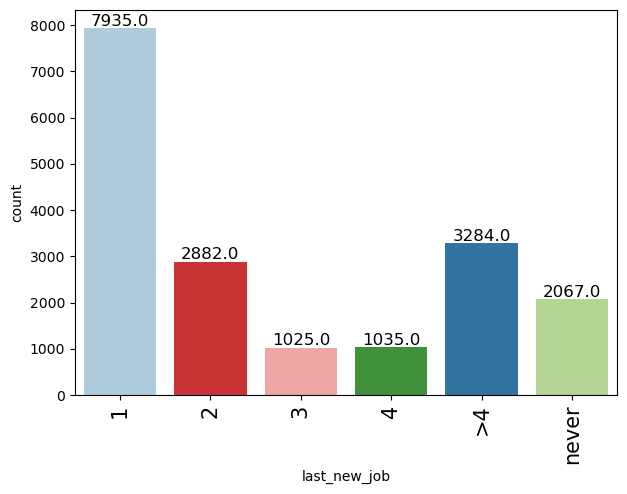

In [126]:
labeled_barplot(df, 'last_new_job')

I think this data is good as is, therefore I am going to one-hot encode it. 

In [127]:
df = pd.get_dummies(df, columns=['last_new_job'], drop_first=True, dtype=int)

In [128]:
df.head(5)

,city,city_development_index,target,gender_Male,gender_Other,relevent_experience_No relevent experience,education_enrollment_Graduate_not_enrolled,education_enrollment_High School_enrolled,education_enrollment_High School_not_enrolled,education_enrollment_Masters_enrolled,...,experience_1_junior,experience_2_mid,experience_3_senior,experience_4_veteran,experience_5_expert,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,0.215054,0.920,1.0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0.138462,0.776,0.0,1,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0.592359,0.624,0.0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0.388889,0.789,1.0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0.271186,0.767,0.0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


## Overview

I have now finished my data preprocessing, EDA, and feature engineering on the data. Before I move on to model building I am just going to show a sample of the dataframe to get an idea of what the finalized dataset looks like.

In [129]:
df.head(25)

,city,city_development_index,target,gender_Male,gender_Other,relevent_experience_No relevent experience,education_enrollment_Graduate_not_enrolled,education_enrollment_High School_enrolled,education_enrollment_High School_not_enrolled,education_enrollment_Masters_enrolled,...,experience_1_junior,experience_2_mid,experience_3_senior,experience_4_veteran,experience_5_expert,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,0.215054,0.920,1.0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0.138462,0.776,0.0,1,0,1,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0.592359,0.624,0.0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0.388889,0.789,1.0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0.271186,0.767,0.0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
5,0.272727,0.764,1.0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,0.234932,0.920,0.0,1,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
7,0.282258,0.762,1.0,1,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
8,0.215054,0.920,1.0,1,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
9,0.215054,0.920,0.0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0


## Model Building

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)
X = df.drop('target',axis=1)   
Y = df['target']   
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)
smote = SMOTE(sampling_strategy=0.75, random_state=1)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)
def model_performance_classification_sklearn_with_threshold(model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics, based on the threshold specified, to check classification model performance
    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    pred = np.round(pred_thres)
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )
    return df_perf

Train set performance:
   Accuracy    Recall  Precision        F1
0  0.770201  0.541903   0.537836  0.539862
Test set performance:
   Accuracy    Recall  Precision        F1
0   0.77217  0.562126    0.53187  0.546579


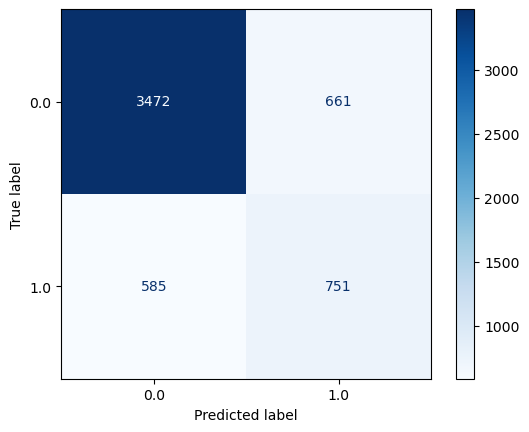

In [131]:
# Fit the model on training set
model = LogisticRegression(solver="liblinear", random_state=1)
lg = model.fit(x_train_res, y_train_res)

# predict on test set
y_predict = model.predict(x_test)

# check the training set performance
log_reg_model_train_perf = model_performance_classification_sklearn_with_threshold(lg, x_train, y_train)
print("Train set performance:")
print(log_reg_model_train_perf)

# check the test set performance
log_reg_model_test_perf = model_performance_classification_sklearn_with_threshold(lg, x_test, y_test)
print("Test set performance:")
print(log_reg_model_test_perf)

# Plot confusion matrix using the new method
cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.show()

Here we can see that my test and train accuracy are relatively close to one another, therefore this is a well done early level machine learning notebook.